# 2. Feature Engineering and Target Construction

Turns the cached raw data into the 64-event modelling table. Cheap to re-run, so this is
where feature changes are iterated.

Two things worth watching in the output below: the **stationarity gate**, which excludes
any feature carrying a unit root before a model ever sees it, and the **damage
provenance** count, which shows how much of the damage signal is real and how much is an
EM-DAT reporting artefact.

## 2.1 Environment and cached inputs

Loads `_shared.py` (paths, the artifact cache helpers, the target definitions) and applies the thesis figure style, then prints the artifact cache so it is visible which upstream stage produced these inputs and when. Reads `market`, `disasters`, `macro` and `sp500` from stage 01.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403  paths, artifact cache, target bounds

from src.visualization import result_figures as fx
fx.apply_thesis_style()

print("stage inputs available in the artifact cache:")
print(artifact_status().to_string(index=False) if len(artifact_status()) else "  (none yet)")

market_clean = load_frame("market")
disasters_raw = load_frame("disasters")
macro = load_frame("macro")
sp500 = load_frame("sp500")
print(f"\nloaded: market={len(market_clean)} rows, disasters={len(disasters_raw)}, "
      f"macro={len(macro)}, sp500={len(sp500)}")


stage inputs available in the artifact cache:
                     artifact               written_utc rows                                                                                                                                                                                  note
              final_rf_models 2026-09-19T08:58:38+00:00                                                                                                                      RandomForest refit on all real rows per target, for SHAP in stage 07.
         pca_ablation_results 2026-09-19T08:58:04+00:00                                                                                      PCA(10)+Ridge vs RF-selected top-20+Ridge, same folds -- reported comparison, not adopted by default.
            results_ablations 2026-09-19T08:58:20+00:00                                                                                                                                Split-geometry (20/5/5) and feature-count 

## 2.2 Market features

**What.** Build the pre event market state features: lagged returns, price relative to
moving averages, rolling volatility at several windows including a dedicated thirty session
window, a conditional volatility forecast, and the pre event volume block.

**Why.** These describe what the market was already doing before the disaster. Without them
there is no way to ask the study's central question, which is whether disaster information
adds anything beyond the market's own condition.

**Later use.** They form the market only information set used as a baseline in the return
grid, and they are candidates for selection in every model in stages 04 and 05.

**Justification.** Every rolling window is computed on the price series shifted by one
session, so a value at the event never includes the event day itself. That shift is part of
the definition, not an implementation detail: an unshifted twenty session average at the
event would contain the shock it is supposed to predict. The dedicated thirty session
volatility window mirrors the thirty session volume baseline that defines the volume target,
so the volatility and volume measures are on the same footing.

Damage figures are taken from the source's own inflation adjusted column where it exists,
and from the unadjusted figure as a documented fallback where it does not. The fallback is
recorded in a provenance column rather than applied silently.


In [2]:
from src.features.feature_engineering import FeatureEngineer

fe = FeatureEngineer()

market_feats = fe.engineer_market_features(market_clean)
print("Engineered market features:")
print([c for c in market_feats.columns if c not in ("date", "aspi_close", "trading_volume", "price_source", "volume_source")])


Engineered market features:
['log_return', 'lag_return_t-1', 'lag_return_t-2', 'lag_return_t-3', 'lag_return_t-5', 'sma_5', 'ema_5', 'price_to_sma_5', 'price_to_ema_5', 'sma_10', 'ema_10', 'price_to_sma_10', 'price_to_ema_10', 'sma_20', 'ema_20', 'price_to_sma_20', 'price_to_ema_20', 'rolling_std_5', 'rolling_std_10', 'rolling_std_20', 'rolling_std_30', 'squared_return', 'garch_cond_vol', 'vol_ratio_1_30', 'vol_ratio_5_30', 'vol_ratio_10_30', 'vol_cv_30', 'log_vol_change_1']


### 2.2.1 Stationarity check

Augmented Dickey-Fuller and KPSS on every engineered market column, not just on
`log_return`. The moving-average columns are rolling means of a price level that
climbs from about 574 to over 10,000 across the sample; under a chronological split a
non-stationary feature puts the test fold outside any range the model saw in training.

In [3]:
import warnings

from statsmodels.tsa.stattools import adfuller, kpss

# Stationarity verification (thesis \u00a73.5.1). An earlier version of this cell tested
# log_return ALONE and reported "stationary", while six engineered price-level columns
# (sma_5/10/20, ema_5/10/20) went untested -- they are rolling means of the raw ASPI
# index, which runs from ~574 in 2000 to over 10,000 by 2022. Under a chronological
# split that guarantees the test fold occupies a feature range the training fold never
# saw. Every engineered market feature is now tested, and the verdict decides which
# columns are admitted to the model (see the EXCLUDE_COLS block in \u00a77).
#
# Convention: ADF null = has a unit root (want p < 0.05); KPSS null = is stationary
# (want p > 0.05). Only the ADF result gates exclusion -- see the reasoning in
# stationarity_verdict below.
def stationarity_verdict(series: pd.Series):
    s = series.dropna()
    if len(s) < 30 or s.nunique() < 3:
        return None, None, "too few observations"
    adf_p = adfuller(s)[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # KPSS warns when p is clipped at a table bound
        kpss_p = kpss(s, nlags="auto")[1]
    # The disqualifying condition for a CHRONOLOGICAL split is a UNIT ROOT: a series
    # whose level wanders without reverting, so a later test fold occupies a range the
    # training fold never saw. That is exactly what ADF tests, so failing to reject its
    # null (p >= 0.05) is the exclusion criterion.
    #
    # KPSS is reported but does NOT gate inclusion. The volatility columns
    # (rolling_std_*, squared_return) reject the ADF unit-root null decisively
    # (p ~ 1e-11 or smaller) while still failing KPSS level-stationarity -- the ordinary
    # signature of persistent, mean-reverting volatility clustering, not of a trending
    # level. Excluding those would discard the thesis's own mandated 30-day panic proxy
    # (Sec. 3.5.2) over a property that creates no extrapolation risk. An earlier version
    # of this cell required both tests to agree and dropped 11 of 22 features on that
    # mistake.
    if adf_p >= 0.05:
        verdict = "UNIT ROOT (excluded)"
    elif kpss_p > 0.05:
        verdict = "stationary"
    else:
        verdict = "persistent, mean-reverting (kept)"
    return adf_p, kpss_p, verdict


market_feature_cols = [
    c for c in market_feats.columns
    if c not in ("date", "aspi_close", "trading_volume", "price_source", "volume_source")
    and pd.api.types.is_numeric_dtype(market_feats[c])
]

# Development-period-only stationarity gate (methodology-audit followup, finding #26):
# this decision used to run ADF/KPSS on the FULL market series -- every test fold's own
# date range included in the very computation that decides which columns that fold is
# even allowed to see. A unit-root verdict is data-driven (unlike a purely theoretical
# admissibility rule), so it must be made from a genuine development slice that predates
# every walk-forward test fold, not from the whole timeline. `_DEV_TRAIN_WINDOW` mirrors
# TRAIN_WINDOW declared in \u00a78 below (hardcoded here, not imported, since this cell runs
# before that one -- a mismatch would only ever make the development window too WIDE or
# too NARROW relative to fold 0's actual test start, not silently wrong in a way that
# reintroduces leakage into a later fold, since every fold after fold 0 starts later
# still). The qualifying-event filter is the same `engineer_disaster_features` \u00a72.x
# below already applies -- computed here too since this cell runs first; cheap, and
# idempotent when \u00a72.x recomputes it.
_DEV_TRAIN_WINDOW = 30
_dev_events = fe.engineer_disaster_features(disasters_raw).sort_values("event_date")
_dev_cutoff_date = (_dev_events["event_date"].iloc[_DEV_TRAIN_WINDOW - 1]
                    if len(_dev_events) > _DEV_TRAIN_WINDOW else _dev_events["event_date"].max())
market_feats_dev = market_feats[market_feats["date"] < _dev_cutoff_date]
print(f"stationarity gate computed on {len(market_feats_dev)} of {len(market_feats)} market "
      f"rows (development period ending {_dev_cutoff_date.date()}, before fold 0's first test "
      f"event) -- never on rows inside any walk-forward test fold.\n")

stationarity_rows = []
for col in market_feature_cols:
    adf_p, kpss_p, verdict = stationarity_verdict(market_feats_dev[col])
    stationarity_rows.append({"feature": col, "adf_p": adf_p, "kpss_p": kpss_p, "verdict": verdict})
stationarity_table = pd.DataFrame(stationarity_rows)

NON_STATIONARY_COLS = stationarity_table.loc[
    stationarity_table["verdict"] == "UNIT ROOT (excluded)", "feature"
].tolist()
print(f"{len(NON_STATIONARY_COLS)} of {len(market_feature_cols)} engineered market features "
      f"carry a unit root and are excluded from the model in \u00a77:")
for col in NON_STATIONARY_COLS:
    print(f"  - {col}")
print()
stationarity_table


stationarity gate computed on 1632 of 6266 market rows (development period ending 2006-10-26, before fold 0's first test event) -- never on rows inside any walk-forward test fold.



6 of 28 engineered market features carry a unit root and are excluded from the model in §7:
  - sma_5
  - ema_5
  - sma_10
  - ema_10
  - sma_20
  - ema_20



,feature,adf_p,kpss_p,verdict
0,log_return,2.515598e-14,0.100000,stationary
1,lag_return_t-1,2.619846e-14,0.100000,stationary
2,lag_return_t-2,2.513212e-14,0.100000,stationary
3,lag_return_t-3,2.472994e-14,0.100000,stationary
4,lag_return_t-5,2.613742e-14,0.100000,stationary
5,sma_5,9.837271e-01,0.010000,UNIT ROOT (excluded)
6,ema_5,9.824094e-01,0.010000,UNIT ROOT (excluded)
7,price_to_sma_5,8.491071e-12,0.100000,stationary
8,price_to_ema_5,4.722215e-11,0.100000,stationary
9,sma_10,9.861291e-01,0.010000,UNIT ROOT (excluded)


## 2.3 Disaster features and the inclusion filter

Builds the severity, hazard-magnitude and disaster-type columns, and applies the
inclusion filter: biological events excluded, and `population_affected` at or above
the configured threshold.

In [4]:
disaster_feats = fe.engineer_disaster_features(disasters_raw)
print(f"After thesis inclusion filter (>=1000 affected, exclude Biological/epidemic events): {disaster_feats.shape[0]} qualifying disasters")
print(disaster_feats["disaster_type"].value_counts())
print(f"\nThesis's own claimed scope (\u00a73.5.4/\u00a77.3): N \u2248 50-86 qualifying events. "
      f"Actual filtered count ({disaster_feats.shape[0]}) falls inside that range -- real sanity check passed.")


After thesis inclusion filter (>=1000 affected, exclude Biological/epidemic events): 94 qualifying disasters
disaster_type
Flood      69
Storm      15
Drought     7
Other       3
Name: count, dtype: int64

Thesis's own claimed scope (§3.5.4/§7.3): N ≈ 50-86 qualifying events. Actual filtered count (94) falls inside that range -- real sanity check passed.


### 2.3.1 Threshold transparency check

**Transparency check, not a scope change:** the thesis mandates the `>=1000 affected` threshold (§3.3.2), that stays the modeled scope, unchanged, everywhere in this notebook. This is only a read of how many additional real EM-DAT records exist at other thresholds, so the choice of 1000 is visibly a real constraint, not an unexamined one.

In [5]:
clean_type = disasters_raw["disaster_type"].astype(str).str.strip().str.lower()
non_bio = disasters_raw[~clean_type.isin({"epidemic", "biological", "biological disaster", "pandemic"})]

print("Non-biological EM-DAT records qualifying at each affected-threshold (current thesis threshold: 1000):")
for thresh in (100, 500, 1000, 5000, 10000):
    n = int((non_bio["population_affected"].fillna(0) > thresh).sum())
    marker = "  <-- current modeled scope" if thresh == 1000 else ""
    print(f"  > {thresh:>6,d} affected: {n:>3d} records{marker}")


Non-biological EM-DAT records qualifying at each affected-threshold (current thesis threshold: 1000):
  >    100 affected: 100 records
  >    500 affected:  96 records
  >  1,000 affected:  94 records  <-- current modeled scope
  >  5,000 affected:  89 records
  > 10,000 affected:  80 records


## 2.4 Scope: which events the market series can carry

An event is modelled only if the ASPI series covers its full 90-trading-day recovery
window. Stage 01 now extends that series past the old 2023-06-28 archive cutoff using
countryeconomy.com, so ten previously-excluded events enter the study, including both
Storm Ditwah dates.

The inclusion filter itself is unchanged: the same pre-registered >=1000-affected,
natural-disaster, non-epidemic criteria apply. Only the market series got longer.

In [6]:
from src.config.settings import STUDY_END, assert_events_within_study_period, market_data_bound

# The market series is already truncated by stage 01 at the last session the study's
# windows can reach; this cell re-derives that bound so the notebook records it.
MARKET_BOUND = market_data_bound(disaster_feats["event_date"], sessions=market_clean["date"])
ARCHIVE_END = market_clean["date"].max()
in_scope = disaster_feats[(disaster_feats["event_date"] <= ARCHIVE_END)
                          & (disaster_feats["event_date"] <= STUDY_END)].copy()
out_of_scope = disaster_feats[~disaster_feats.index.isin(in_scope.index)].copy()

# A modelled event after the declared end of the study period is a scope drift, not a
# data point. Raise rather than let the period widen silently (T10).
assert_events_within_study_period(in_scope["event_date"])

print(f"Study period ends:            {STUDY_END.date()}")
print(f"Market series ends:           {ARCHIVE_END.date()}  (bound {MARKET_BOUND.date()})")
print(f"In-scope disasters (modeled):      {in_scope.shape[0]}")
print(f"Out-of-scope disasters (excluded): {out_of_scope.shape[0]}")
out_of_scope[["event_date", "disaster_type", "event_name"]]


Study period ends:            2025-12-31
Market series ends:           2026-04-16  (bound 2026-04-16)
In-scope disasters (modeled):      94
Out-of-scope disasters (excluded): 0


,event_date,disaster_type,event_name


## 2.5 Target construction

**What.** Compute the three research targets for every qualifying event, together with the
date on which each target's label is actually settled.

**Why.** These three quantities are the entire research question. Everything downstream is an
attempt to predict them.

**Later use.** The targets and their settlement dates go into `dataset.parquet`. The
settlement dates are what the fold boundary purge compares against, so a training event whose
label depends on prices dated on or after the first test event can be removed.

**Justification, target by target.**

1. **ASPI percentage change** is the forward log return in percent from the last pre event
   close, `100 ln(P at t plus 5 / P at t minus 1)`, where `t` is the first trading session on
   or after the disaster date. It is baselined on the previous close rather than on the event
   day close because every feature is snapshotted as of the previous session. Baselining on
   the event day close would measure a return from a price the model has not been given,
   and it would exclude the day zero reaction, which is the part of the response most likely
   to carry the disaster's effect.
2. **Volume crash magnitude** is event day volume over its own trailing thirty session mean,
   minus one. Both terms are known on the event day itself, so this target has no forward
   horizon and needs no embargo.
3. **Market recovery days** counts trading sessions, never calendar days, until the index
   regains its pre event level. It is right censored at ninety sessions or at the arrival of
   the next qualifying disaster, whichever is earlier, with the reason recorded.

**A structural property of the recovery target that must be stated before any recovery result
is read.** The recovery clock only starts if the index actually falls below its pre event
level within a five session window. If it never does, the event is genuinely resilient and
the duration is zero. If it does, the clock starts at that trough rather than at the event.
Without that gate an event whose own close happened to sit above the baseline would score
zero immediately, even when the index fell a few sessions later. Even with the gate, this
target remains zero inflated and right censored, which is why the primary recovery analysis
uses a censored survival likelihood rather than a squared error loss.


In [7]:
targets = fe.build_targets(market_clean, in_scope)
print(f"Targets built for {targets.shape[0]} in-scope events")
targets.describe()


Targets built for 74 in-scope events


,event_date,prediction_origin_session,P0,Y1_ASPI_5D_Forward_LogReturn_Pct,Y1_horizon_end_date,Y2_5D_Forward_AbnormalVolume_LogRatio,Y2_horizon_end_date,Y2_V_base,Y2_V_future5,Y3_ASPI_Recovery_Time,...,Y1_ASPI_20D_Forward_LogReturn_Pct,Y1_20D_horizon_end_date,Y2_1D_Forward_AbnormalVolume_LogRatio,Y2_1D_horizon_end_date,Y2_10D_Forward_AbnormalVolume_LogRatio,Y2_10D_horizon_end_date,Y2_20D_Forward_AbnormalVolume_LogRatio,Y2_20D_horizon_end_date,Y2_5D_Forward_AbnormalVolume_Pct,Y2_5D_Forward_AbnormalVolume_LogRatio_Winsorised
count,74,74,74.000000,74.000000,74,61.000000,61,6.200000e+01,6.100000e+01,74.000000,...,74.000000,74,61.000000,61,61.000000,61,61.000000,61,61.000000,61.000000
mean,2015-02-20 09:24:19.459459584,2015-02-21 03:14:35.675675648,6340.692027,0.338996,2015-02-26 10:22:42.162162176,-0.134270,2014-04-29 08:39:20.655737600,6.153051e+07,6.711251e+07,14.256757,...,1.476089,2015-03-21 16:32:25.945945856,-0.349333,2014-04-24 02:45:14.754098432,-0.078308,2014-05-07 12:59:00.983606528,0.019649,2014-05-22 18:29:30.491803392,3.165363,-0.131189
min,2000-09-18 00:00:00,2000-09-18 00:00:00,407.300000,-5.396537,2000-09-22 00:00:00,-1.464356,2001-09-07 00:00:00,2.538108e+06,1.473804e+06,0.000000,...,-11.403822,2000-10-16 00:00:00,-2.039376,2001-09-03 00:00:00,-1.345496,2001-09-14 00:00:00,-1.575924,2001-09-28 00:00:00,-76.877305,-1.083937
25%,2009-11-26 18:00:00,2009-11-28 06:00:00,2964.172500,-0.965736,2009-12-02 06:00:00,-0.494088,2009-11-27 00:00:00,2.084095e+07,1.665774e+07,0.000000,...,-3.210265,2009-12-26 18:00:00,-0.756374,2009-11-23 00:00:00,-0.476710,2009-12-07 00:00:00,-0.484280,2009-12-21 00:00:00,-38.987302,-0.494088
50%,2015-10-15 12:00:00,2015-10-16 00:00:00,6230.985000,-0.120776,2015-10-21 00:00:00,-0.083420,2014-06-10 00:00:00,4.504184e+07,2.995158e+07,4.000000,...,0.027079,2015-11-13 00:00:00,-0.424559,2014-06-04 00:00:00,-0.069558,2014-06-18 00:00:00,0.081569,2014-07-02 00:00:00,-8.003495,-0.083420
75%,2020-12-24 12:00:00,2020-12-26 18:00:00,7214.065000,1.197491,2020-12-31 06:00:00,0.321129,2019-10-30 00:00:00,7.147678e+07,8.027479e+07,14.500000,...,6.153444,2021-01-24 18:00:00,0.150134,2019-10-24 00:00:00,0.293787,2019-11-06 00:00:00,0.435478,2019-11-22 00:00:00,37.868352,0.321129
max,2025-11-27 00:00:00,2025-11-27 00:00:00,23029.860000,8.796710,2025-12-03 00:00:00,1.120317,2022-12-13 00:00:00,3.823754e+08,6.445515e+08,90.000000,...,18.717933,2025-12-26 00:00:00,1.079142,2022-12-06 00:00:00,1.258830,2022-12-20 00:00:00,1.153699,2023-01-04 00:00:00,206.582732,0.726752
std,NaN,NaN,4140.391811,2.679665,NaN,0.593772,NaN,6.437833e+07,1.035229e+08,24.786795,...,6.686817,NaN,0.671910,NaN,0.580705,NaN,0.624063,NaN,59.991023,0.551668


### 2.5.2 Market adjusted abnormal returns

The sample spans March 2020 and the 2022 Sri Lankan economic crisis, so a raw index move
can register as a disaster effect when the cause was global. A single factor market model,
`r_aspi = alpha + beta * r_sp500`, is fitted on the 250 daily sessions ending strictly
before each event's prediction origin, and the abnormal return is what the index actually
did minus what that model expected. Only the coefficients are restricted to pre origin
data; the realised market factor inside the event window is an observation, not a forecast.

The raw forward return stays the primary target. These columns are reported beside it so
the robustness suite can compare the two on identical folds (Revision 2, T6).


In [8]:
from src.config.settings import ABNORMAL_RETURN_HORIZONS
from src.targets.abnormal_returns import (abnormal_return_col, align_market_factor,
                                          build_abnormal_return_targets)

# The market model needs the ASPI daily return and the market factor on ONE calendar.
# The S&P and the CSE keep different holidays, so the factor is accumulated and
# differenced onto CSE sessions rather than joined on the date, which would leave holes
# that void whole event windows.
_daily = market_feats[["date", "aspi_close", "log_return"]].sort_values("date").reset_index(drop=True)
_daily["sp500_log_return"] = align_market_factor(
    _daily["date"], sp500["date"], sp500["sp500_log_return"])
print(f"market factor on CSE sessions: {_daily['sp500_log_return'].notna().sum()}/{len(_daily)}")

# Keyed on the event date, NOT concatenated positionally: `targets` carries only the
# events that aligned to a session, so a positional join would attach a value to the
# wrong event.
_abn_events = targets["event_date"].reset_index(drop=True)
abnormal = build_abnormal_return_targets(_daily, _abn_events, ABNORMAL_RETURN_HORIZONS)
abnormal.insert(0, "event_date", _abn_events)
targets = targets.merge(abnormal, on="event_date", how="left", validate="one_to_one")

print(f"Abnormal-return columns built for {len(abnormal)} events")
print(f"median fitted beta on the S&P 500: {abnormal['market_model_beta'].median():.3f}")
for _h in ABNORMAL_RETURN_HORIZONS:
    _col = abnormal_return_col(_h)
    print(f"  h={_h:2d}: {targets[_col].notna().sum():2d}/{len(targets)} observed, "
          f"mean {targets[_col].mean():+.3f} pct")


market factor on CSE sessions: 6264/6266


Abnormal-return columns built for 74 events
median fitted beta on the S&P 500: 0.017
  h= 1: 74/74 observed, mean -0.059 pct
  h= 5: 74/74 observed, mean +0.055 pct
  h=10: 74/74 observed, mean +0.394 pct
  h=15: 74/74 observed, mean +0.462 pct
  h=20: 74/74 observed, mean +0.402 pct


### 2.5.1 Inspect the constructed targets

A first look at the five target columns before anything is modelled. `NaN` here is
meaningful, it marks events whose volume was never recorded, and those events are
dropped from Y2 by the per-target mask rather than filled.

In [9]:
targets.head(10)


,event_date,prediction_origin_session,P0,Y1_ASPI_5D_Forward_LogReturn_Pct,Y1_horizon_end_date,Y2_5D_Forward_AbnormalVolume_LogRatio,Y2_horizon_end_date,Y2_V_base,Y2_V_future5,Y3_ASPI_Recovery_Time,...,Y1_5D_abnormal_horizon_end_date,Y1_ASPI_10D_Forward_AbnormalReturn_Pct,Y1_10D_abnormal_horizon_end_date,Y1_ASPI_15D_Forward_AbnormalReturn_Pct,Y1_15D_abnormal_horizon_end_date,Y1_ASPI_20D_Forward_AbnormalReturn_Pct,Y1_20D_abnormal_horizon_end_date,market_model_alpha,market_model_beta,market_model_n
0,2000-09-18,2000-09-18,496.80,2.700720,2000-09-22,NaN,NaT,NaN,NaN,3.0,...,2000-09-22,6.037039,2000-09-29,5.807222,2000-10-06,3.717787,2000-10-16,-0.000836,0.002029,167
1,2000-11-18,2000-11-20,477.70,-3.819131,2000-11-24,NaN,NaT,NaN,NaN,26.0,...,2000-11-24,-7.881507,2000-12-01,-7.317639,2000-12-08,-3.419934,2000-12-15,-0.000846,0.010269,211
2,2000-12-24,2000-12-27,449.30,-0.557975,2001-01-03,NaN,NaT,NaN,NaN,7.0,...,2001-01-03,1.088770,2001-01-11,1.984567,2001-01-19,-0.187736,2001-01-26,-0.001014,0.009249,236
3,2001-09-01,2001-09-03,407.30,0.196223,2001-09-07,-1.022944,2001-09-07,4.099196e+06,1473804.0,5.0,...,2001-09-07,1.444945,2001-09-14,-1.156330,2001-09-21,0.717465,2001-09-28,-0.000768,0.011116,250
4,2002-12-16,2002-12-16,781.30,2.139999,2002-12-23,-0.037947,2002-12-23,2.538108e+06,2443600.0,3.0,...,2002-12-23,2.720580,2002-12-31,3.192388,2003-01-08,4.288331,2003-01-16,0.001464,-0.045906,250
5,2003-05-17,2003-05-19,844.80,-0.999295,2003-05-23,-0.048383,2003-05-23,4.981221e+06,4745952.0,2.0,...,2003-05-23,0.345621,2003-05-30,4.739665,2003-06-06,7.538869,2003-06-13,0.001280,0.003050,250
6,2004-12-11,2004-12-13,1521.06,1.060066,2004-12-17,0.056792,2004-12-17,7.858847e+06,8318080.0,0.0,...,2004-12-17,-1.381252,2004-12-28,-1.391458,2005-01-04,0.317813,2005-01-11,0.001090,-0.380647,250
7,2004-12-26,2004-12-28,1572.55,-4.108567,2005-01-03,-0.447537,2005-01-03,7.810033e+06,4992180.0,13.0,...,2005-01-03,-2.251124,2005-01-10,-2.235734,2005-01-18,0.591028,2005-01-27,0.001420,-0.330910,250
8,2005-11-21,2005-11-21,2328.92,-5.396537,2005-11-25,0.409284,2005-11-25,2.015914e+07,30354400.0,90.0,...,2005-11-25,-4.630153,2005-12-02,-10.033607,2005-12-09,-12.651264,2005-12-19,0.001756,-0.181673,250
9,2006-10-26,2006-10-26,2507.42,-1.229501,2006-11-01,0.060540,2006-11-01,1.661007e+07,17646700.0,7.0,...,2006-11-01,2.005072,2006-11-08,6.150611,2006-11-15,5.978997,2006-11-22,-0.000019,0.062597,250


## 2.6 Assembling the event-level table

Each qualifying disaster becomes one training row: its own exogenous features (damage, population, type), the market's engineered endogenous features **as of the day before the event** (never the shock day itself, enforced explicitly here via `asof_date = event_date - 1`, on top of the feature-level shift already applied in §4), and the macro/global control values as of that same date.

(Repo note: `feature_engineering.build_feature_table()` exists but is designed as a running daily panel with disaster info merge_asof'd backward, useful for a different framing, not directly for this one-row-per-event table. Assembled directly here instead, to avoid a column-collision it produces when composed with a second event-level merge.)

In [10]:
events_sorted = in_scope.sort_values("event_date").copy()
events_sorted["asof_date"] = events_sorted["event_date"] - pd.Timedelta(days=1)

# Disaster recency features, built from the real event dates with no new source.
# days_since_last_disaster: gap to the previous in-scope event. The very first
# event has no predecessor -- filled with a fixed 10-year sentinel (3650 days)
# representing "no recent in-scope disaster", not a fabricated average.
gap_days = events_sorted["event_date"].diff().dt.days
events_sorted["days_since_last_disaster"] = gap_days.fillna(3650.0)


def _trailing_count(dates: pd.Series, window_days: int = 365) -> list[int]:
    d = dates.values
    return [int(((d > (di - np.timedelta64(window_days, "D"))) & (d < di)).sum()) for di in d]


events_sorted["disasters_trailing_365d"] = _trailing_count(events_sorted["event_date"])

snap = pd.merge_asof(
    events_sorted.sort_values("asof_date"), market_feats.sort_values("date"),
    left_on="asof_date", right_on="date", direction="backward",
)
snap = pd.merge_asof(
    snap.sort_values("asof_date"),
    macro[["date", "gdp_growth_pct", "inflation_cpi_pct", "gdp_current_usd"]].sort_values("date"),
    left_on="asof_date", right_on="date", direction="backward", suffixes=("", "_macro"),
)
snap = pd.merge_asof(
    snap.sort_values("asof_date"), sp500.sort_values("date"),
    left_on="asof_date", right_on="date", direction="backward", suffixes=("", "_gspc"),
)

# New: damage-to-GDP ratio -- ties disaster magnitude to the economy's
# real scale that year, which raw log-damage alone doesn't capture. Both
# financial_damage and gdp_current_usd are already in raw USD (not '000s) --
# see emdat_loader.py and macro_loader.py docstrings.
snap["damage_to_gdp"] = (snap["financial_damage"] / snap["gdp_current_usd"]).replace([np.inf, -np.inf], np.nan)

dataset = pd.merge(snap, targets, on="event_date", how="inner").sort_values("event_date").reset_index(drop=True)

# External data blocks A-D, specified in docs/EXTERNAL_DATA_PRE_DECLARATION.md
# Written and committed BEFORE any of these features was scored, per integrity
# constraint 2. Four sources, all reachability-tested, all cached offline:
#
#   A hazard NASA POWER daily precipitation and wind, 7 district points. Measured
#                 by instrument, so unlike financial_damage it has no reporting bias and
#                 no missingness -- and it is knowable on the event day, which makes it
#                 admissible in the ex-ante Model A specification.
#   B desinventar UNDRR/UNDP national loss database, district-level physical severity.
#                 Carries NO monetary loss (valorus is populated in 0 of 130,018
#                 records), so it substitutes for the missing damage figures in physical
#                 terms only. Ends 2020-12-20; di_available flags that.
#   C fx FRED DEXSLUS daily LKR/USD, replacing an ANNUAL macro series matched
#                 against day-0 events. All three terms use data at or before t-1, the
#                 same pre-shock boundary as the ASPI features.
#   D election Wikidata national election dates. The 2005-11-17 presidential election
#                 falls 4 days before the 2005-11-21 event that carries the largest
#                 observed Y1 drop.
#
# Motivation, measured: financial_damage is real for 17/64 events and zero-filled for 47.
# Every column below is 100% covered on all events.
from src.data.external_sources import (
    EXTERNAL_FEATURE_BLOCKS, build_all_external_features)

EXTERNAL_CACHE = ARTIFACT_DIR / "external"
external_feats = build_all_external_features(dataset["event_date"], EXTERNAL_CACHE)
dataset = dataset.merge(external_feats, on="event_date", how="left")

print("External feature coverage (non-null %, all events):")
for _blk, _cols in EXTERNAL_FEATURE_BLOCKS.items():
    _cov = dataset[_cols].notna().mean().mul(100).round(1)
    print(f"  {_blk:12s} {_cov.min():5.1f}-{_cov.max():5.1f}%  ({len(_cols)} features)")
print(f"  DesInventar matched: {int(dataset['di_available'].sum())}/{len(dataset)} events "
      f"(the database ends 2020-12-20)")
print(f"  events within +/-5 days of a national election: "
      f"{int(dataset['election_within_5d'].sum())}")
print()

# New: one limited interaction term (Flood only -- 51/74 of the
# qualifying set, the only type with enough rows for an interaction to mean
# anything at this N; all 5 type interactions were considered and rejected
# as too many features for N~64).
# np.where, not a plain product: NaN * 0.0 == NaN in float arithmetic, which would make
# every non-Flood event's interaction term spuriously NaN whenever damage is missing
# (methodology-audit finding #14 fix surfaced this -- financial_damage/log_financial_damage
# can now be real NaN). Only a FLOOD event can have a genuinely missing interaction
# value; every non-Flood event is definitionally 0, never "missing".
dataset["log_damage_x_flood"] = np.where(
    dataset["disaster_Flood"] == 1, dataset["log_financial_damage"], 0.0)

# Missingness flags for the feature-level `.fillna(0.0)` below (methodology-audit
# finding #14): without these, a zero-filled volume ratio / GARCH forecast / macro rate
# is indistinguishable from a genuinely-observed zero. One flag per group of columns
# that are always missing TOGETHER (same underlying data gap -- volume absent for 2000
# and post-2023, GARCH needing enough history to fit, an annual macro series not yet
# published for the most recent events), not one per column, to avoid manufacturing
# near-duplicate near-constant features. `deaths_available`/`homeless_available`/
# `mag_area_available`/`mag_wind_available`/`di_available`/`financial_damage_observed`
# already cover the EM-DAT/DesInventar severity columns (emdat_loader.py); this closes
# the remaining gap.
_vol_ratio_cols = [c for c in ("vol_ratio_1_30", "vol_ratio_5_30", "vol_ratio_10_30",
                                "vol_cv_30", "log_vol_change_1") if c in dataset.columns]
if _vol_ratio_cols:
    dataset["volume_features_available"] = dataset[_vol_ratio_cols].notna().all(axis=1).astype(float)
if "garch_cond_vol" in dataset.columns:
    dataset["garch_cond_vol_available"] = dataset["garch_cond_vol"].notna().astype(float)
if "gdp_growth_pct" in dataset.columns:
    dataset["macro_available"] = (dataset["gdp_growth_pct"].notna()
                                  & dataset["inflation_cpi_pct"].notna()).astype(float)

# TARGET_COLS is imported from _shared.py so the list lives in ONE place, and the
# exclusions are DERIVED from it rather than repeating the names. A target that is not
# excluded silently becomes a feature, and a forward-looking target used as a feature is
# a catastrophic leak. Not hypothetical: adding the longer forward return horizons put
# them straight into FEATURE_COLS on the first run, which would have let every model
# read the future it was being asked to predict.
# The assertion below turns any repeat into a hard failure.
TARGET_COLS = list(TARGET_COLS)   # the list imported from _shared.py

EXCLUDE_COLS = {
    "event_date", "asof_date", "date", "date_macro", "date_gspc", "disaster_type", "disaster_group",
    "disaster_subgroup", "damage_source", "dis_no", "event_name", "aspi_close", "trading_volume",
    "price_source", "volume_source", "event_date_precision",
    "gdp_current_usd",  # used only to derive damage_to_gdp, not a feature itself
    # Y3 competing-risk censoring detail (methodology-audit finding #7). Y3_censored is
    # bool, which pandas' is_numeric_dtype treats as numeric -- excluded explicitly so it
    # is never auto-admitted as a feature (Y3_censor_reason is a string and is already
    # excluded by the numeric-dtype filter below, listed here anyway for visibility).
    "Y3_censored", "Y3_censor_reason",
    # Y3 adverse-response gate detail (methodology-audit finding #11) -- computed from
    # POST-event prices, same reason as Y3_censored above: diagnostic only, never a
    # feature.
    "Y3_drawdown_occurred",
}
EXCLUDE_COLS |= NON_FEATURE_COLS   # targets, their constituents, audit + label-end cols
# Columns the stationarity tests in \u00a74 rejected. These are the raw ASPI price
# levels (sma_*/ema_*): retained in the market table because the price-relative
# ratios are computed FROM them, but never fed to a model. Their stationary
# counterparts (price_to_sma_*, price_to_ema_*) carry the same momentum signal.
# Driven by the test result, not by held-out performance.
EXCLUDE_COLS |= set(NON_STATIONARY_COLS)
FEATURE_COLS = [c for c in dataset.columns if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(dataset[c])]
# The mutually-exclusive one-hot block, declared explicitly rather than sniffed by
# prefix: SMOGN must copy these verbatim instead of blending them, and must only
# pair events that share a type.
TYPE_COLS = [c for c in FEATURE_COLS if c.startswith("disaster_")]

assert_no_target_leakage(FEATURE_COLS)

# What the damage features actually measure. EM-DAT records no damage estimate for
# most Sri Lankan events, and the loader zero-fills those -- so these columns behave
# substantially as an indicator of EM-DAT REPORTING COVERAGE, which is itself
# correlated with event severity and recency, rather than as a clean severity
# measure. Printed for the modelled subset, since the raw-file figure is the wrong
# denominator.
if "damage_source" in dataset.columns:
    print("Damage provenance across the modelled events:")
    print(dataset["damage_source"].value_counts().to_string())
    _has_damage = (dataset["financial_damage"] > 0).sum()
    print(f"  events with a non-zero damage figure: {_has_damage}/{len(dataset)}")
    if "disaster_Flood" in dataset.columns:
        _flood_dmg = int(((dataset["financial_damage"] > 0) & (dataset["disaster_Flood"] == 1)).sum())
        print(f"  of which floods, the support of the log_damage_x_flood term: {_flood_dmg}")
    print()

# Y3 window contamination -- FIXED (methodology-audit finding #7, 2026-09-16):
# `event_targets.build_event_targets` caps each event's recovery search at
# min(90, days_to_next_qualifying_disaster) directly, using TRADING-day positions (not
# the calendar-day proxy below), and records the outcome in `Y3_censored`/
# `Y3_censor_reason`. `preprocessor.truncate_overlapping_windows()` remains unused --
# superseded by the in-line fix rather than wired in -- and is not the mechanism this
# count is now describing. Kept as a calendar-day sanity count, not a remaining gap:
_gaps = dataset["event_date"].diff().dt.days.shift(-1)
print(f"Events with another qualifying disaster within 90 calendar days (informational; "
      f"Y3 itself is now capped on the actual trading-day gap, see Y3_censor_reason): "
      f"{int((_gaps <= 90).sum())}/{len(dataset)}")
print(f"Y3_censor_reason breakdown: "
      f"{dataset['Y3_censor_reason'].value_counts().to_dict() if 'Y3_censor_reason' in dataset.columns else 'n/a'}")
print()

X = dataset[FEATURE_COLS].fillna(0.0)
# Targets keep their NaNs. A missing target is a missing OBSERVATION, not a zero:
# Y2 is absent for 3 events whose source workbook failed to parse, and filling them
# with 0.0 would assert "volume exactly at its 30-day baseline" -- a fabricated
# measurement, in a study whose central claim is that it uses only real data.
# Section 9 drops these rows per target instead.
y = dataset[TARGET_COLS].copy()
missing_targets = y.isna().sum()
if missing_targets.any():
    print("Missing target values (rows dropped per target, never imputed):")
    for _t, _n in missing_targets[missing_targets > 0].items():
        _dates = dataset.loc[y[_t].isna(), "event_date"].dt.date.tolist()
        print(f"  {_t}: {_n} missing -> effective N={len(y) - _n}; events {_dates}")

print(f"Final training table: {X.shape[0]} events x {X.shape[1]} features")
print(f"Feature columns: {FEATURE_COLS}")
dataset[["event_date", "disaster_type"] + TARGET_COLS].head(10)


External feature coverage (non-null %, all events):
  hazard       100.0-100.0%  (6 features)
  desinventar  100.0-100.0%  (7 features)
  fx           100.0-100.0%  (3 features)
  election     100.0-100.0%  (2 features)
  DesInventar matched: 52/74 events (the database ends 2020-12-20)
  events within +/-5 days of a national election: 1

Damage provenance across the modelled events:
damage_source
missing_median_imputed    56
emdat_cpi_adjusted        18
  events with a non-zero damage figure: 18/74
  of which floods, the support of the log_damage_x_flood term: 12

Events with another qualifying disaster within 90 calendar days (informational; Y3 itself is now capped on the actual trading-day gap, see Y3_censor_reason): 35/74
Y3_censor_reason breakdown: {'recovered': 36, 'no_drawdown': 22, 'next_disaster': 10, '90_day_cap': 6}

Missing target values (rows dropped per target, never imputed):
  Y2_5D_Forward_AbnormalVolume_LogRatio: 13 missing -> effective N=61; events [datetime.date(2000

,event_date,disaster_type,Y1_ASPI_5D_Forward_LogReturn_Pct,Y2_5D_Forward_AbnormalVolume_LogRatio,Y3_ASPI_Recovery_Time,Y1_ASPI_10D_Forward_LogReturn_Pct
0,2000-09-18,Flood,2.700720,NaN,3.0,5.196738
1,2000-11-18,Flood,-3.819131,NaN,26.0,-8.767767
2,2000-12-24,Storm,-0.557975,NaN,7.0,0.088988
3,2001-09-01,Drought,0.196223,-1.022944,5.0,0.636321
4,2002-12-16,Flood,2.139999,-0.037947,3.0,4.235161
5,2003-05-17,Flood,-0.999295,-0.048383,2.0,1.631970
6,2004-12-11,Flood,1.060066,0.056792,0.0,-1.100667
7,2004-12-26,Other,-4.108567,-0.447537,13.0,-0.282743
8,2005-11-21,Flood,-5.396537,0.409284,90.0,-3.117321
9,2006-10-26,Flood,-1.229501,0.060540,7.0,2.002219


## 2.7 Chronological partitioning and time aware oversampling

**What.** Cut the chronological walk forward folds once, and illustrate what the
oversampling does to a training fold.

**Why.** Fixing the folds here, in one place, means every later stage scores exactly the same
events, so no stage can quietly change what it is being measured on.

**Later use.** `splits.pkl` is loaded by stages 04, 05 and 06, and by the experiment scripts.

**Justification.** Ordinary shuffled cross validation is not admissible here. It randomly
reorders the sequence, so a training row's outcome can be measured from prices a test row has
already seen. Every split in this project is chronological: training events always precede
test events.

The oversampling shown below is an illustration only. In the modelling stages it is applied
inside each fold, to that fold's real training rows, after the purge. Applying it once
globally before cutting folds would let synthetic interpolated rows land inside a held out
test split, so a fold's held out score would partly be measuring the model against points
that were fabricated from the training data. That is the same category of error as shuffling,
applied to augmentation instead of to splitting.


In [11]:
from src.training.walk_forward import generate_walk_forward_splits

TRAIN_WINDOW, TEST_WINDOW, STEP = 30, 10, 10  # small windows given N -- see \u00a712 limitations

# Real disaster count only (64) -- NOT len(X_res). Computing splits on the
# post-SMOGN length was a real bug (found during this review): synthetic rows
# sit at the tail of X_res, so a fold boundary cut on that inflated length
# could place fabricated interpolated rows inside a "held-out" test fold --
# scoring the model against its own synthetic output instead of a real event.
splits = list(generate_walk_forward_splits(len(X), train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, step=STEP))
print(f"Walk-forward folds: {len(splits)} (computed on the {len(X)} real events, not the post-SMOGN count)")
for i, s in enumerate(splits):
    assert s.train_index.max() < s.test_index.min(), "chronological violation -- must never happen"
print("All folds verified strictly chronological (no look-ahead).")


Walk-forward folds: 4 (computed on the 74 real events, not the post-SMOGN count)
All folds verified strictly chronological (no look-ahead).


## 2.8 Cache the modelling table

Writes the event table, the feature specification and the fold definitions to
`artifacts/`. Every modelling stage from here on reads these rather than rebuilding
them, which is what keeps the folds identical across stages 04, 05 and 06.

### 2.8.1 Sample selection flow accounting

Every exclusion between the raw EM-DAT export and the modelled events, counted at the
stage that applies it. The table reuses the pipeline's own predicates and constants, so it
cannot drift from what actually ran, and the arithmetic is asserted here and again in
`tests/test_sample_flow.py` (Revision 2, T12).


cached sample_flow.parquet (6 rows by 4 columns)


saved -> docs\figures\eda_11_sample_flow.png (108 KB)
                        stage                                                                      criterion  n_removed  n_remaining
           raw EM-DAT records                                                              none, as exported          0          110
       disaster type excluded disaster_type in ['biological', 'biological disaster', 'epidemic', 'pandemic']          9          101
 below the affected threshold                                                     population_affected < 1000          7           94
prediction origin unalignable                                  no trading session on or after the event date          0           94
           no pre-event close    the aligned session is the first in the market series, so P0 does not exist         20           74
     incomplete target vector                      neither the return nor the recovery target could be built          0           74


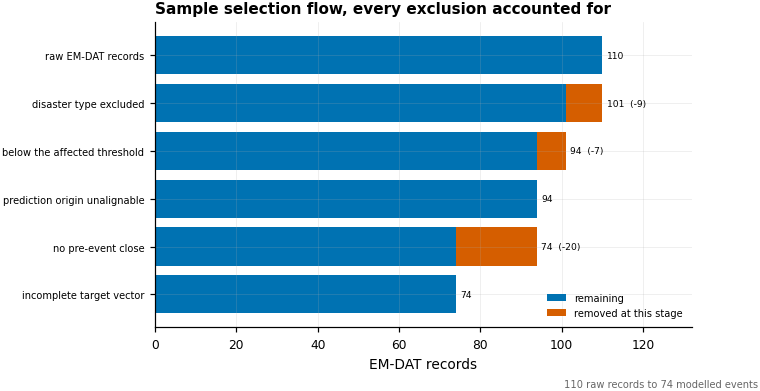

In [12]:
from src.features.feature_engineering import build_sample_flow
from src.visualization import eda_figures as _ef

sample_flow = build_sample_flow(disasters_raw, market_clean)

# The chain must close: each stage's remaining count is the previous one minus what it
# removed. A table that does not reconcile is worse than no table.
for _i in range(1, len(sample_flow)):
    _prev = sample_flow["n_remaining"].iloc[_i - 1]
    assert _prev - sample_flow["n_removed"].iloc[_i] == sample_flow["n_remaining"].iloc[_i]
assert sample_flow["n_remaining"].iloc[-1] == len(dataset)

save_frame(sample_flow, "sample_flow",
           "Exclusions from the raw EM-DAT export to the modelled events.")
_ef.plot_sample_flow(sample_flow)
print(sample_flow.to_string(index=False))


In [13]:
save_frame(dataset, "dataset", f"{len(dataset)} in-scope events x {len(FEATURE_COLS)} features.")
save_frame(market_feats, "market_feats", "Engineered daily market features.")
save_frame(in_scope, "in_scope", "EM-DAT events inside the archive window.")
# Global (all-real-rows) median for the flagged columns (methodology-audit finding #14),
# saved so every "refit on ALL data" consumer -- notebook 04's final SHAP refit,
# scripts/train_final_models.py, and src/models/inference.py's live demo -- imputes with the
# SAME numbers instead of each recomputing its own. This is deliberately NOT used
# inside any walk-forward fold (those use median_impute_from_train on that fold's real
# training rows only); it is only for the already-in-sample "refit on everything" path.
_median_cols_present = [c for c in MEDIAN_IMPUTE_COLS if c in dataset.columns]
median_impute_values = dataset[_median_cols_present].median().fillna(0.0).to_dict()

# Availability at the prediction origin, recorded per feature so a reader never has to
# infer whether a result is a forecast or an ex post attribution (Revision 2, T1).
from src.targets.return_horizons import availability_class

AVAILABILITY_CLASS = {c: availability_class(c) for c in FEATURE_COLS}
print("features by availability:",
      {k: sum(v == k for v in AVAILABILITY_CLASS.values()) for k in ("real_time", "ex_post")})

save_json({"FEATURE_COLS": FEATURE_COLS, "TARGET_COLS": TARGET_COLS, "TYPE_COLS": TYPE_COLS,
           "NON_STATIONARY_COLS": sorted(NON_STATIONARY_COLS),
           "AVAILABILITY_CLASS": AVAILABILITY_CLASS,
           "MEDIAN_IMPUTE_VALUES": median_impute_values}, "feature_spec")
save_object(splits, "splits", f"{len(splits)} chronological walk-forward folds (train/test/step = {TRAIN_WINDOW}/{TEST_WINDOW}/{STEP}).")


cached dataset.parquet (74 rows by 134 columns)


cached market_feats.parquet (6266 rows by 33 columns)


cached in_scope.parquet (94 rows by 26 columns)
features by availability: {'real_time': 37, 'ex_post': 31}
cached feature_spec.json


cached splits.pkl


WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/models/splits.pkl')

## 2.9 Final Outputs

This stage produces the single event level table that every modelling stage reads.

1. `dataset.parquet`: one row per in scope disaster, holding the engineered features, the
   three research targets, the censoring detail for recovery duration and the label end
   dates used for purging.
2. `market_feats.parquet`: the daily market feature series, kept separately because the
   expected return model in `scripts/run_y1_improvement.py` needs daily rows.
3. `in_scope.parquet`: the events that survived the inclusion filter and could be aligned
   to a tradable session.
4. `feature_spec.json`: the frozen feature list, the type columns, the non stationary
   exclusions and the global median impute values.
5. `splits.pkl`: the chronological walk forward fold definitions, fixed here so that every
   later stage scores exactly the same events.
6. No figure is produced and no model is fitted.
7. Consumed next by `03_eda_diagnostics.ipynb` for description, and by
   `04_modeling_regression.ipynb` and `05_modeling_classification.ipynb` for fitting.

Execution assumption: stage 01 has run, so the four input tables exist in the cache.
